<a href="https://colab.research.google.com/github/navyax7/Data-Analysis-Project/blob/main/Cyclistic_Bike_Share_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [9]:
# Load the datasets
q1_2019 = pd.read_csv("Divvy_Trips_2019_Q1.csv")
q1_2020 = pd.read_csv("Divvy_Trips_2020_Q1.csv")

# Compare the column names of both datasets
print("Columns for Q1 2019:")
print(q1_2019.columns)

print("\nColumns for Q1 2020:")
print(q1_2020.columns)

# Inspect the structure of both datasets
print("\nQ1 2019 Data Info:")
q1_2019.info()

print("\nQ1 2020 Data Info:")
q1_2020.info()

# Display the first 5 rows
print("\nFirst 5 rows of Q1 2019:")
display(q1_2019.head())

print("\nFirst 5 rows of Q1 2020:")
display(q1_2020.head())

Columns for Q1 2019:
Index(['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration',
       'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear'],
      dtype='object')

Columns for Q1 2020:
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')

Q1 2019 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365069 entries, 0 to 365068
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   trip_id            365069 non-null  int64  
 1   start_time         365069 non-null  object 
 2   end_time           365069 non-null  object 
 3   bikeid             365069 non-null  int64  
 4   tripduration       365069 non-null  object 
 5   from_stati

,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,390.0,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Subscriber,Male,1989.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,441.0,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Subscriber,Female,1990.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,829.0,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Subscriber,Female,1994.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,"1,783.0",123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Subscriber,Male,1993.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,364.0,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Subscriber,Male,1994.0



First 5 rows of Q1 2020:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,EACB19130B0CDA4A,docked_bike,2020-01-21 20:06:59,2020-01-21 20:14:30,Western Ave & Leland Ave,239,Clark St & Leland Ave,326.0,41.9665,-87.6884,41.9671,-87.6674,member
1,8FED874C809DC021,docked_bike,2020-01-30 14:22:39,2020-01-30 14:26:22,Clark St & Montrose Ave,234,Southport Ave & Irving Park Rd,318.0,41.9616,-87.6660,41.9542,-87.6644,member
2,789F3C21E472CA96,docked_bike,2020-01-09 19:29:26,2020-01-09 19:32:17,Broadway & Belmont Ave,296,Wilton Ave & Belmont Ave,117.0,41.9401,-87.6455,41.9402,-87.6530,member
3,C9A388DAC6ABF313,docked_bike,2020-01-06 16:17:07,2020-01-06 16:25:56,Clark St & Randolph St,51,Fairbanks Ct & Grand Ave,24.0,41.8846,-87.6319,41.8918,-87.6206,member
4,943BC3CBECCFD662,docked_bike,2020-01-30 08:37:16,2020-01-30 08:42:48,Clinton St & Lake St,66,Wells St & Hubbard St,212.0,41.8856,-87.6418,41.8899,-87.6343,member


In [10]:
# Rename Q1 2019 columns to match the Q1 2020 dataset
q1_2019 = q1_2019.rename(columns={
    'trip_id': 'ride_id',
    'bikeid': 'rideable_type',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'from_station_name': 'start_station_name',
    'from_station_id': 'start_station_id',
    'to_station_name': 'end_station_name',
    'to_station_id': 'end_station_id',
    'usertype': 'member_casual'
})

# Convert key columns to strings so they stack consistently
q1_2019['ride_id'] = q1_2019['ride_id'].astype(str)
q1_2019['rideable_type'] = q1_2019['rideable_type'].astype(str)

# Combine the two datasets
all_trips = pd.concat([q1_2019, q1_2020], ignore_index=True)

# Remove columns that are not needed for this analysis
all_trips = all_trips.drop(
    columns=[
        'start_lat', 'start_lng', 'end_lat', 'end_lng',
        'birthyear', 'gender', 'tripduration'
    ],
    errors='ignore'
)

# Check the combined dataset
print("Column names:")
print(all_trips.columns)

print("\nNumber of rows:", len(all_trips))

print("\nDimensions:", all_trips.shape)

print("\nFirst 5 rows:")
display(all_trips.head())

print("\nData types and column information:")
all_trips.info()

print("\nStatistical summary:")
display(all_trips.describe())

Column names:
Index(['ride_id', 'started_at', 'ended_at', 'rideable_type',
       'start_station_id', 'start_station_name', 'end_station_id',
       'end_station_name', 'member_casual'],
      dtype='object')

Number of rows: 791956

Dimensions: (791956, 9)

First 5 rows:


,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,199,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,Subscriber
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,44,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),Subscriber
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,15,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),Subscriber
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,123,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,Subscriber
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,173,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,Subscriber



Data types and column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791956 entries, 0 to 791955
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             791956 non-null  object 
 1   started_at          791956 non-null  object 
 2   ended_at            791956 non-null  object 
 3   rideable_type       791956 non-null  object 
 4   start_station_id    791956 non-null  int64  
 5   start_station_name  791956 non-null  object 
 6   end_station_id      791955 non-null  float64
 7   end_station_name    791955 non-null  object 
 8   member_casual       791956 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 54.4+ MB

Statistical summary:


,start_station_id,end_station_id
count,791956.000000,791955.000000
mean,204.400294,204.379354
std,158.919132,159.323552
min,2.000000,2.000000
25%,77.000000,77.000000
50%,174.000000,174.000000
75%,291.000000,291.000000
max,675.000000,675.000000


In [11]:
# Check the values in the member_casual column before cleaning
print("Rider types before cleaning:")
print(all_trips['member_casual'].value_counts())

# Standardize rider type labels
all_trips['member_casual'] = all_trips['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})

# Check the values after cleaning
print("\nRider types after cleaning:")
print(all_trips['member_casual'].value_counts())


# Convert start and end times to datetime format
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'])


# Create additional date/time variables
all_trips['date'] = all_trips['started_at'].dt.date
all_trips['month'] = all_trips['started_at'].dt.month
all_trips['day'] = all_trips['started_at'].dt.day
all_trips['year'] = all_trips['started_at'].dt.year
all_trips['day_of_week'] = all_trips['started_at'].dt.day_name()


# Calculate ride length in seconds
all_trips['ride_length'] = (
    all_trips['ended_at'] - all_trips['started_at']
).dt.total_seconds()


# Check the updated dataset
print("\nUpdated data information:")
all_trips.info()

print("\nFirst 5 rows with the new variables:")
display(all_trips.head())

Rider types before cleaning:
member_casual
member        378407
Subscriber    341906
casual         48480
Customer       23163
Name: count, dtype: int64

Rider types after cleaning:
member_casual
member    720313
casual     71643
Name: count, dtype: int64

Updated data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791956 entries, 0 to 791955
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             791956 non-null  object        
 1   started_at          791956 non-null  datetime64[ns]
 2   ended_at            791956 non-null  datetime64[ns]
 3   rideable_type       791956 non-null  object        
 4   start_station_id    791956 non-null  int64         
 5   start_station_name  791956 non-null  object        
 6   end_station_id      791955 non-null  float64       
 7   end_station_name    791955 non-null  object        
 8   member_casual       791956 non-

,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual,date,month,day,year,day_of_week,ride_length
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,199,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,member,2019-01-01,1,1,2019,Tuesday,390.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,44,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),member,2019-01-01,1,1,2019,Tuesday,441.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,15,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),member,2019-01-01,1,1,2019,Tuesday,829.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,123,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,member,2019-01-01,1,1,2019,Tuesday,1783.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,173,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,member,2019-01-01,1,1,2019,Tuesday,364.0


In [12]:
# Remove "bad" data
# The data frame includes entries where bikes were taken out of docks for quality checks or ride_length was negative
# Create a new version of the data frame (v2) since data is being removed
all_trips_v2 = all_trips[(all_trips['start_station_name'] != "HQ QR") & (all_trips['ride_length'] >= 0)].copy()


In [13]:
#==============================
# CONDUCT DESCRIPTIVE ANALYSIS
#==============================

# Descriptive analysis on ride_length (all figures in seconds)
print("\nDescriptive statistics for ride_length:\n", all_trips_v2['ride_length'].describe())

# Compare members and casual users
print("\nRide length statistics grouped by member_casual:\n", all_trips_v2.groupby('member_casual')['ride_length'].agg(['mean', 'median', 'max', 'min']))

# See the average ride time by each day for members vs casual users
print("\nAverage ride length by member type and day of the week:\n", all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean())

# Order the days of the week for correct sorting for analysis
days_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
all_trips_v2['day_of_week'] = pd.Categorical(all_trips_v2['day_of_week'], categories=days_order, ordered=True)

# Now, run the aggregation again to see the sorted result
print("\nAverage ride length (sorted by day of week):\n", all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean())

# Analyze ridership data by type and weekday
summary_stats = all_trips_v2.groupby(['member_casual', 'day_of_week']).agg(
    number_of_rides=('ride_id', 'count'),
    average_duration=('ride_length', 'mean')
).reset_index()

print("\nSummary of rides and duration by rider type and weekday:\n", summary_stats)

# You can further explore the data by examining specific relationships between values.
# For example:
# The number of rides by rider type and weekday
# The average ride duration by rider type and weekday



Descriptive statistics for ride_length:
 count    7.881890e+05
mean     1.189459e+03
std      3.329191e+04
min      1.000000e+00
25%      3.310000e+02
50%      5.390000e+02
75%      9.120000e+02
max      1.063202e+07
Name: ride_length, dtype: float64

Ride length statistics grouped by member_casual:
                       mean  median         max  min
member_casual                                      
casual         5372.783874  1393.0  10632022.0  2.0
member          795.252339   508.0   6096428.0  1.0

Average ride length by member type and day of the week:
 member_casual  day_of_week
casual         Friday         6090.737302
               Monday         4752.050438
               Saturday       4950.770801
               Sunday         5061.304364
               Thursday       8451.666853
               Tuesday        4561.803857
               Wednesday      4480.372432
member         Friday          796.733789
               Monday          822.311202
               Saturday   

/tmp/ipykernel_1361/1892250206.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("\nAverage ride length (sorted by day of week):\n", all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean())
/tmp/ipykernel_1361/1892250206.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = all_trips_v2.groupby(['member_casual', 'day_of_week']).agg(



Average ride length (sorted by day of week):
 member_casual  day_of_week
casual         Sunday         5061.304364
               Monday         4752.050438
               Tuesday        4561.803857
               Wednesday      4480.372432
               Thursday       8451.666853
               Friday         6090.737302
               Saturday       4950.770801
member         Sunday          972.938336
               Monday          822.311202
               Tuesday         769.441629
               Wednesday       711.983790
               Thursday        707.209274
               Friday          796.733789
               Saturday        974.072964
Name: ride_length, dtype: float64

Summary of rides and duration by rider type and weekday:
    member_casual day_of_week  number_of_rides  average_duration
0         casual      Sunday            18652       5061.304364
1         casual      Monday             5591       4752.050438
2         casual     Tuesday             7311       4

In [14]:
#==========================================
# EXPORT SUMMARY FILE FOR FURTHER ANALYSIdS
#==========================================

# Create a .csv file that you will visualize elsewhere
counts = all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean().reset_index()
counts.to_csv('avg_ride_length.csv', index=False)


/tmp/ipykernel_1361/2495355057.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean().reset_index()


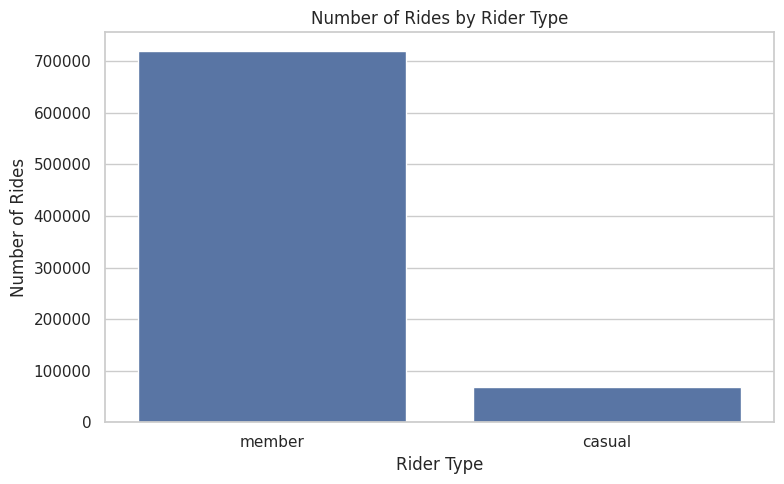

In [15]:
# Number of rides by rider type

ride_counts = all_trips_v2['member_casual'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=ride_counts.index,
    y=ride_counts.values
)

plt.title("Number of Rides by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Number of Rides")
plt.tight_layout()
plt.show()

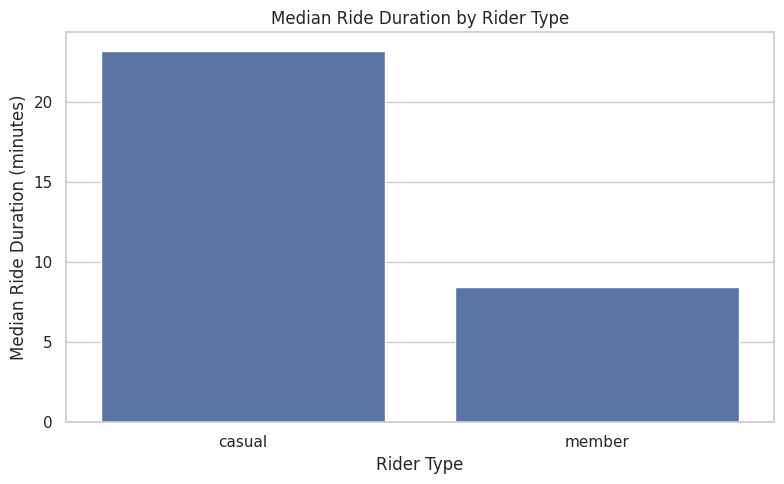

In [16]:
# Median ride duration by rider type

median_duration = (
    all_trips_v2
    .groupby('member_casual')['ride_length']
    .median()
    .reset_index()
)

# Convert seconds to minutes
median_duration['ride_length_minutes'] = (
    median_duration['ride_length'] / 60
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=median_duration,
    x='member_casual',
    y='ride_length_minutes'
)

plt.title("Median Ride Duration by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Median Ride Duration (minutes)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1361/46355520.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['member_casual', 'day_of_week'])


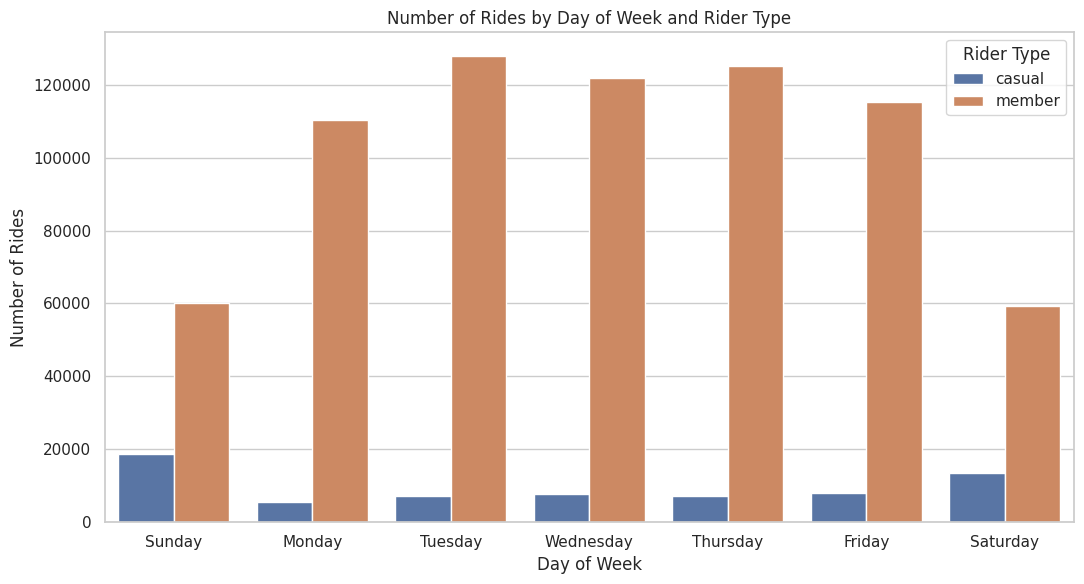

In [17]:
# Number of rides by rider type and day of week

days_order = [
    "Sunday", "Monday", "Tuesday",
    "Wednesday", "Thursday", "Friday", "Saturday"
]

rides_by_day = (
    all_trips_v2
    .groupby(['member_casual', 'day_of_week'])
    .size()
    .reset_index(name='number_of_rides')
)

rides_by_day['day_of_week'] = pd.Categorical(
    rides_by_day['day_of_week'],
    categories=days_order,
    ordered=True
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=rides_by_day,
    x='day_of_week',
    y='number_of_rides',
    hue='member_casual'
)

plt.title("Number of Rides by Day of Week and Rider Type")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")
plt.legend(title="Rider Type")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1361/2866144017.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['member_casual', 'day_of_week'])['ride_length']


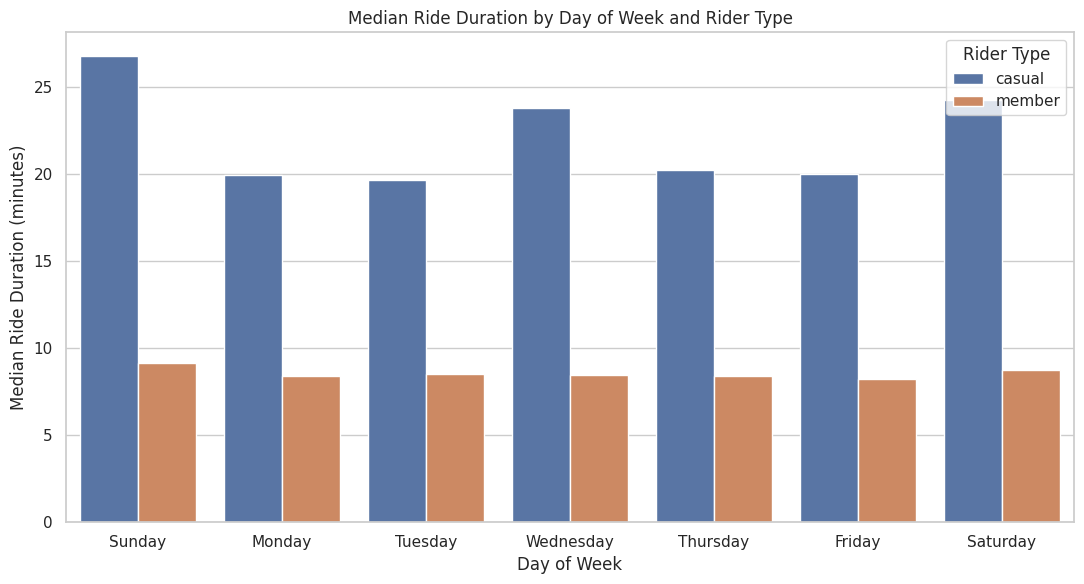

In [18]:
# Median ride duration by day of week and rider type

duration_by_day = (
    all_trips_v2
    .groupby(['member_casual', 'day_of_week'])['ride_length']
    .median()
    .reset_index()
)

duration_by_day['ride_length_minutes'] = (
    duration_by_day['ride_length'] / 60
)

duration_by_day['day_of_week'] = pd.Categorical(
    duration_by_day['day_of_week'],
    categories=days_order,
    ordered=True
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=duration_by_day,
    x='day_of_week',
    y='ride_length_minutes',
    hue='member_casual'
)

plt.title("Median Ride Duration by Day of Week and Rider Type")
plt.xlabel("Day of Week")
plt.ylabel("Median Ride Duration (minutes)")
plt.legend(title="Rider Type")
plt.tight_layout()
plt.show()

Conclusion

The analysis shows clear differences in how Cyclistic's casual riders and annual members use the service. Members account for a substantially higher number of rides and tend to take shorter rides, with a median ride duration of approximately 8.5 minutes compared with approximately 23 minutes for casual riders. Casual riders also show relatively greater usage on weekends, while member usage is concentrated more strongly on weekdays.

These patterns suggest that the two rider groups have distinct usage behaviours. Members appear to use Cyclistic more frequently and for shorter trips, while casual riders use the service less frequently but tend to take longer rides and show stronger weekend usage. These differences provide a basis for developing targeted strategies to encourage casual riders to transition to annual memberships.

However, the analysis also identified extreme ride-duration outliers, so median ride duration was used as a more robust measure than the mean when interpreting typical rider behaviour.